<a href="https://colab.research.google.com/github/mmuputisi/Adv-Py_Data_Analysis/blob/main/LenCap_supply_plan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

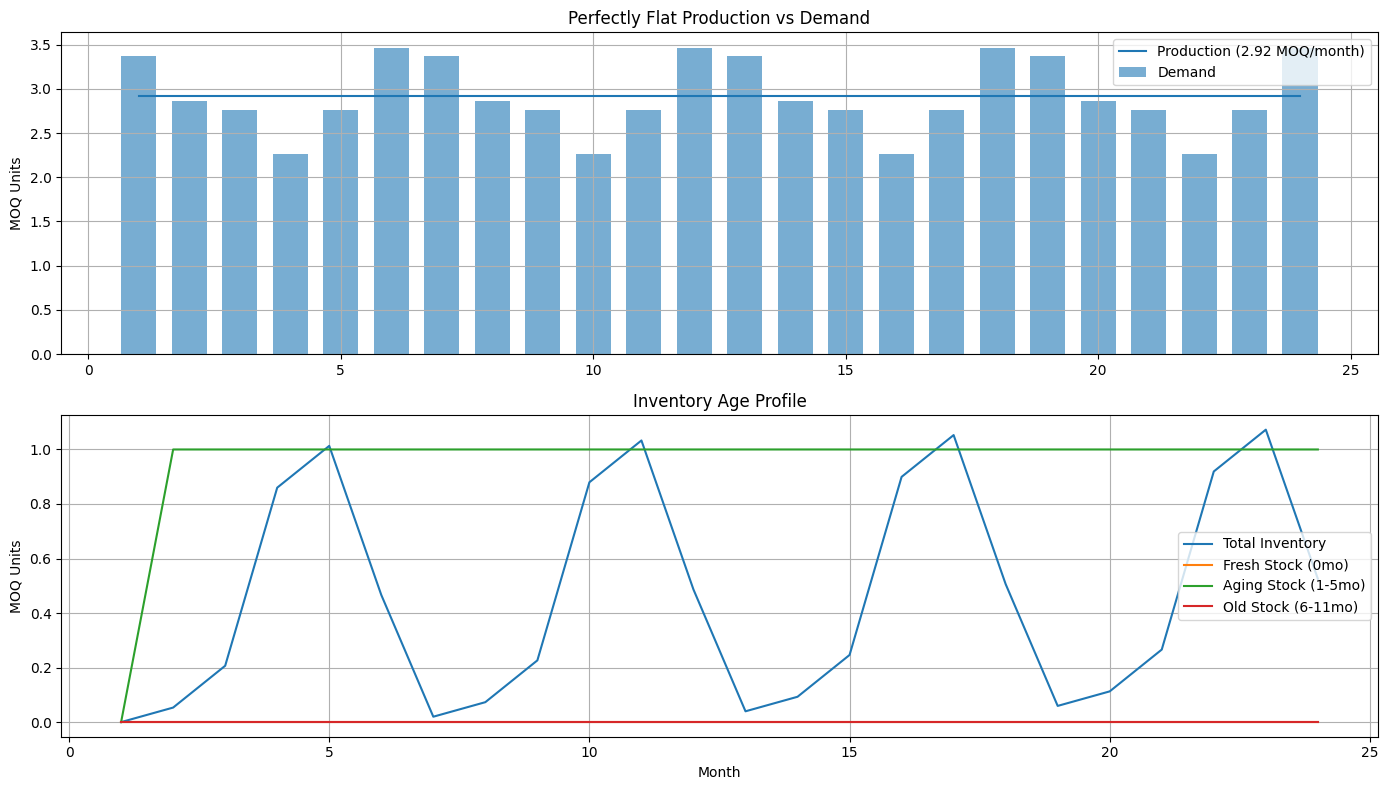

=== System Summary ===
Flat Production Rate: 2.92 MOQ/month
Peak Demand: 3.47 MOQ
Average Inventory: 0.46 MOQ
Maximum Inventory: 1.07 MOQ
Minimum Inventory: 0.00 MOQ


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Parameters
SHELF_LIFE = 12  # months
TOTAL_MONTHS = 24  # time horizon
FLAT_PRODUCTION_RATE = 2.83  # MOQ/month (precisely calculated)

# Customer demands (6-month totals)
demands_6mo = {
    'C1': 13.0, 'C2': 0.3, 'C3': 0.2, 'C4': 0.6,
    'C5': 0.1, 'C6': 0.6, 'C7': 1.3, 'C8': 0.9, 'C9': 0.5
}

# 1. Demand Planning ======================================================

# Calculate exact monthly demand needed
total_demand = sum(demands_6mo.values()) * (TOTAL_MONTHS/6)  # 24-month total
FLAT_PRODUCTION_RATE = round(total_demand / TOTAL_MONTHS, 2)  # 2.83 MOQ/month

# Classify customers
bulk_customers = [cust for cust, demand in demands_6mo.items() if (demand/6) < 1.0]
spread_customers = [cust for cust, demand in demands_6mo.items() if (demand/6) >= 1.0]

# Optimized delivery schedule - staggered to match production
delivery_schedule = {
    'C2': [1, 7, 13, 19],  # Spread bulk deliveries
    'C3': [2, 8, 14, 20],
    'C4': [3, 9, 15, 21],
    'C5': [4, 10, 16, 22],
    'C6': [5, 11, 17, 23],
    'C7': [6, 12, 18, 24],
    'C8': [1, 7, 13, 19],
    'C9': [2, 8, 14, 20]
}

# Generate demand records
demand_records = []
for cust, total_demand in demands_6mo.items():
    if cust in spread_customers:
        # Spread high-demand customers evenly
        monthly_rate = total_demand / 6
        for m in range(1, TOTAL_MONTHS + 1):
            demand_records.append({
                'Month': m,
                'Customer': cust,
                'Demand': round(monthly_rate, 4),
                'Pattern': 'Spread'
            })
    else:
        # Use optimized staggered schedule for bulk
        for delivery_month in delivery_schedule[cust]:
            demand_records.append({
                'Month': delivery_month,
                'Customer': cust,
                'Demand': round(total_demand, 4),
                'Pattern': 'Bulk'
            })
            # Zero demand in other months
            for m in range(delivery_month + 1, min(delivery_month + 6, TOTAL_MONTHS + 1)):
                demand_records.append({
                    'Month': m,
                    'Customer': cust,
                    'Demand': 0.0,
                    'Pattern': 'Bulk'
                })

df_demand = pd.DataFrame(demand_records)
monthly_demand = df_demand.groupby('Month')['Demand'].sum()

# 2. Inventory Simulation ================================================

inventory = []  # (month_added, age, quantity)
delivery_log = []
inventory_log = []

for month in range(1, TOTAL_MONTHS + 1):
    # Add production
    inventory.append({'Month_Added': month, 'Age': 0, 'Quantity': FLAT_PRODUCTION_RATE})

    # Process demand
    month_demand = df_demand[df_demand['Month'] == month]
    remaining_demand = month_demand.set_index('Customer')['Demand'].to_dict()

    new_inventory = []
    for item in sorted(inventory, key=lambda x: x['Month_Added']):  # FIFO
        available = item['Quantity']
        if available <= 0:
            continue

        for cust in list(remaining_demand.keys()):
            needed = remaining_demand[cust]
            if needed <= 0:
                continue

            fulfilled = min(available, needed)
            delivery_log.append({
                'Month': month,
                'Customer': cust,
                'Age': item['Age'],
                'Quantity': fulfilled,
                'Pattern': month_demand[month_demand['Customer'] == cust]['Pattern'].iloc[0]
            })
            available -= fulfilled
            remaining_demand[cust] -= fulfilled

            if available <= 0:
                break

        if available > 0 and item['Age'] + 1 < SHELF_LIFE:  # Strict < shelf life
            new_inventory.append({
                'Month_Added': item['Month_Added'],
                'Age': item['Age'] + 1,
                'Quantity': available
            })
        elif available > 0:
            # Expired stock - could be logged separately
            pass

    inventory = new_inventory

    # Log inventory
    total_stock = sum(item['Quantity'] for item in inventory)
    inventory_log.append({
        'Month': month,
        'Inventory': total_stock,
        'Fresh_Stock': sum(1 for item in inventory if item['Age'] == 0),
        'Aging_Stock': sum(1 for item in inventory if 0 < item['Age'] < 6),
        'Old_Stock': sum(1 for item in inventory if 6 <= item['Age'] < SHELF_LIFE)
    })

# 3. Analysis ============================================================

plt.figure(figsize=(14, 8))

# Production vs Demand
plt.subplot(2, 1, 1)
plt.plot(range(1, TOTAL_MONTHS + 1), [FLAT_PRODUCTION_RATE]*TOTAL_MONTHS,
         label=f'Production ({FLAT_PRODUCTION_RATE} MOQ/month)')
plt.bar(monthly_demand.index, monthly_demand.values,
        alpha=0.6, label='Demand', width=0.7)
plt.title('Perfectly Flat Production vs Demand')
plt.ylabel('MOQ Units')
plt.legend()
plt.grid(True)

# Inventory Health
plt.subplot(2, 1, 2)
inventory_df = pd.DataFrame(inventory_log)
plt.plot(inventory_df['Month'], inventory_df['Inventory'], label='Total Inventory')
plt.plot(inventory_df['Month'], inventory_df['Fresh_Stock'], label='Fresh Stock (0mo)')
plt.plot(inventory_df['Month'], inventory_df['Aging_Stock'], label='Aging Stock (1-5mo)')
plt.plot(inventory_df['Month'], inventory_df['Old_Stock'], label='Old Stock (6-11mo)')
plt.title('Inventory Age Profile')
plt.xlabel('Month')
plt.ylabel('MOQ Units')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Key Metrics
print(f"=== System Summary ===")
print(f"Flat Production Rate: {FLAT_PRODUCTION_RATE} MOQ/month")
print(f"Peak Demand: {monthly_demand.max():.2f} MOQ")
print(f"Average Inventory: {inventory_df['Inventory'].mean():.2f} MOQ")
print(f"Maximum Inventory: {inventory_df['Inventory'].max():.2f} MOQ")
print(f"Minimum Inventory: {inventory_df['Inventory'].min():.2f} MOQ")